In [1]:
!pip install pennylane
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 46.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 91.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import time

# PennyLane imports
import pennylane as qml
from pennylane import numpy as np_qml

In [3]:
# --- Dataset Configuration ---
DATA_DIR = "/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
RANDOM_SEED = 42
NUM_WORKERS = 2

# --- Quantum Configuration ---
N_QUBITS = 4  # Number of qubits
N_LAYERS = 2  # Number of quantum layers

print("Checking dataset directory...")
if not os.path.exists(DATA_DIR):
    print(" DATA_DIR does not exist:", DATA_DIR)
else:
    print(" Found DATA_DIR:", DATA_DIR)

# --- Data Transformations and Loading ---
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Checking dataset directory...
 Found DATA_DIR: /kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast


In [4]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

Classes: ['benign', 'malignant']
Total images: 7909


In [5]:
# Split dataset
train_size = int((1.0 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)

print(f"Split -> Train: {len(train_dataset)}  Val: {len(val_dataset)}")

Split -> Train: 6327  Val: 1582


In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import MobileNet_V3_Small_Weights
import pennylane as qml

In [7]:
# --- Quantum Circuit Definition ---
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Data encoding
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    
    # Variational layers
    for layer in range(N_LAYERS):
        # Fully connected entanglement (all-to-all)
        for i in range(N_QUBITS):
            for j in range(i + 1, N_QUBITS):
                qml.CNOT(wires=[i, j])
        
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RY(weights[layer, i, 1], wires=i)
            qml.RZ(weights[layer, i, 2], wires=i)
    
    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

In [8]:
# --- Quantum Layer ---
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=1):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (n_layers, n_qubits)}
        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

    def forward(self, x):
        if x.size(-1) != self.n_qubits:
            x = x[..., :self.n_qubits]  # project to match qubits
        return self.qlayer(torch.tanh(x))

In [9]:
class HQCNN_MobileNetV3(nn.Module):
    def __init__(self, num_classes, embed_dim=256, use_quantum=True,
                 freeze_backbone=True, n_qubits=4, n_layers=1,
                 classical_width_mult=1.28):
        super().__init__()
        self.use_quantum = use_quantum
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        if use_quantum:
            self.backbone = models.mobilenet_v3_small(
                weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
            )
            feat_dim = self.backbone.classifier[0].in_features
            self.backbone.classifier = nn.Identity()

            if freeze_backbone:
                for p in self.backbone.parameters():
                    p.requires_grad = False
                print(f"Backbone frozen - {sum(p.numel() for p in self.backbone.parameters()):,} params frozen")

            self.proj = nn.Linear(feat_dim, n_qubits)

            self.quantum_layer = QuantumLayer(n_qubits=n_qubits, n_layers=n_layers)
            self.quantum_post = nn.Linear(n_qubits, embed_dim // 2)

            self.classical_branch = nn.Sequential(
                nn.Linear(feat_dim, embed_dim // 2),
                nn.BatchNorm1d(embed_dim // 2),
                nn.ReLU(inplace=True),
                nn.Dropout(0.2)
            )
            effective_dim = embed_dim

        else:
            self.backbone = models.mobilenet_v3_small(
                weights=None,
                num_classes=num_classes,
                width_mult=classical_width_mult
            )
            effective_dim = self.backbone.classifier[0].in_features 

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(effective_dim, max(64, num_classes * 2)),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(max(64, num_classes * 2), num_classes)
        )

    def forward(self, x):
        if self.use_quantum:
            feat = self.backbone(x)
            q_in = self.proj(feat)
            q_out = self.quantum_layer(q_in)
            q_out = self.quantum_post(q_out)

            c_out = self.classical_branch(feat)
            combined = torch.cat([q_out, c_out], dim=1)
            return self.classifier(combined)
        else:
            return self.backbone(x)


In [10]:
def count_parameters(model):
    """Count total and trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [11]:
def measure_inference_time(model, data_loader, device, num_batches=5):
    """Measure average inference time"""
    model.eval()
    times = []
    
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            
            inputs = inputs.to(device)
            
            # Warm up GPU
            if i == 0:
                _ = model(inputs)
                torch.cuda.synchronize() if device.type == 'cuda' else None
            
            start_time = time.time()
            _ = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.time()
            
            times.append(end_time - start_time)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
               device, num_epochs=10, save_path='best_hqcnn_quantum.pth'):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model.to(device)
    
    for epoch in range(num_epochs):
        t0 = time.time()
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = running_corrects.double().item() / total
        
        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total += labels.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_running_corrects.double().item() / val_total
        
        # Update learning rate
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
        
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} '
              f'- Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} - LR: {current_lr:.6f} - Time: {elapsed:.1f}s')
    
    return history

In [14]:
# --- Model Training ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model_classical = HQCNN_MobileNetV3(
    num_classes=len(class_names), 
    use_quantum=False,
    freeze_backbone=False
).to(device)

classical_total, classical_trainable = count_parameters(model_classical)

print(f"\nClassical Model:")
print(f"  Total parameters: {classical_total:,}")
print(f"  Trainable parameters: {classical_trainable:,}")

Device: cuda

Classical Model:
  Total parameters: 2,465,868
  Trainable parameters: 2,465,868


In [15]:
# Training setup
criterion = nn.CrossEntropyLoss()

optimizer_classical = torch.optim.AdamW(model_classical.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_classical = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_classical, patience=2, factor=0.5)

NUM_EPOCHS = 10

print(f"\n=== TRAINING CLASSICAL MODEL ===")
history_classical = train_model(
    model_classical, train_loader, val_loader, criterion, optimizer_classical, scheduler_classical,
    device, num_epochs=NUM_EPOCHS, save_path='best_hqcnn_classical.pth'
)


=== TRAINING CLASSICAL MODEL ===
Epoch 1/10 - Train Loss: 0.4288 Train Acc: 0.8073 - Val Loss: 0.6215 Val Acc: 0.6827 - LR: 0.000100 - Time: 105.7s
Epoch 2/10 - Train Loss: 0.3567 Train Acc: 0.8418 - Val Loss: 0.3678 Val Acc: 0.8287 - LR: 0.000100 - Time: 62.9s
Epoch 3/10 - Train Loss: 0.3229 Train Acc: 0.8636 - Val Loss: 0.3164 Val Acc: 0.8546 - LR: 0.000100 - Time: 62.3s
Epoch 4/10 - Train Loss: 0.2728 Train Acc: 0.8829 - Val Loss: 0.3512 Val Acc: 0.8603 - LR: 0.000100 - Time: 62.4s
Epoch 5/10 - Train Loss: 0.2433 Train Acc: 0.9001 - Val Loss: 0.3029 Val Acc: 0.8824 - LR: 0.000100 - Time: 62.7s
Epoch 6/10 - Train Loss: 0.2062 Train Acc: 0.9196 - Val Loss: 0.3847 Val Acc: 0.8673 - LR: 0.000100 - Time: 62.9s
Epoch 7/10 - Train Loss: 0.1735 Train Acc: 0.9256 - Val Loss: 0.2985 Val Acc: 0.8818 - LR: 0.000100 - Time: 62.7s
Epoch 8/10 - Train Loss: 0.1441 Train Acc: 0.9466 - Val Loss: 0.3608 Val Acc: 0.8812 - LR: 0.000100 - Time: 62.8s
Epoch 9/10 - Train Loss: 0.1257 Train Acc: 0.9523 - V

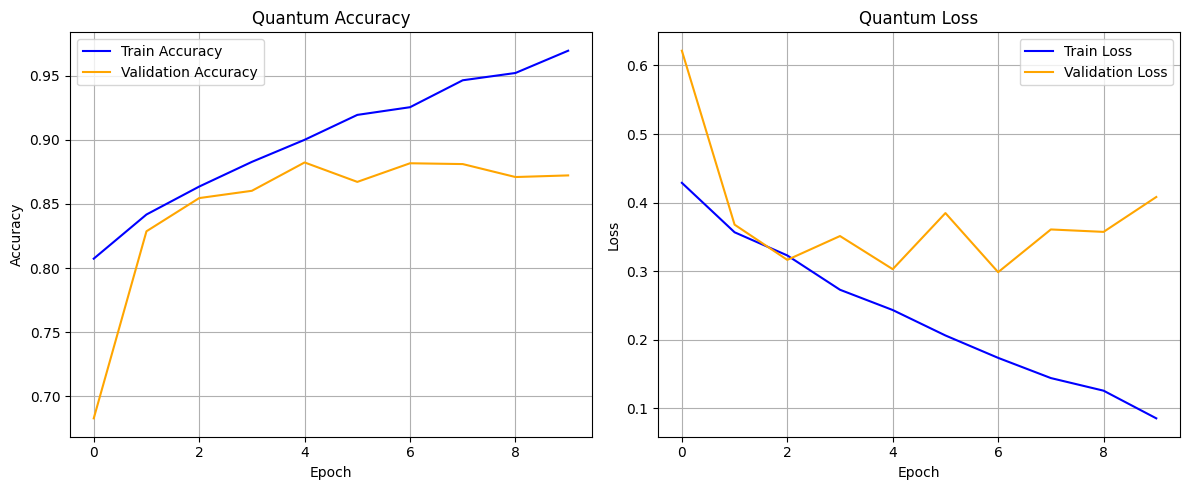

In [16]:
def plot_quantum(history_quantum):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(history_quantum['train_acc'], label='Train Accuracy', color='blue')
    ax1.plot(history_quantum['val_acc'], label='Validation Accuracy', color='orange')
    ax1.set_title('Quantum Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history_quantum['train_loss'], label='Train Loss', color='blue')
    ax2.plot(history_quantum['val_loss'], label='Validation Loss', color='orange')
    ax2.set_title('Quantum Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_quantum(history_classical)

In [17]:
model_classical.load_state_dict(torch.load('best_hqcnn_classical.pth', map_location=device))
classical_time, classical_std = measure_inference_time(model_classical, val_loader, device)
print(f"Classical Model - Avg inference time: {classical_time:.4f}s (±{classical_std:.4f}s)")

Classical Model - Avg inference time: 0.0095s (±0.0022s)


In [18]:
def evaluate_model(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    
    return all_labels, all_preds

all_labels_c, all_preds_c = evaluate_model(model_classical, val_loader, device, class_names)
print('\nClassical Model - Classification Report:')
print(classification_report(all_labels_c, all_preds_c, target_names=class_names))


Classical Model - Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.86      0.82       502
   malignant       0.93      0.89      0.91      1080

    accuracy                           0.88      1582
   macro avg       0.86      0.88      0.87      1582
weighted avg       0.89      0.88      0.88      1582



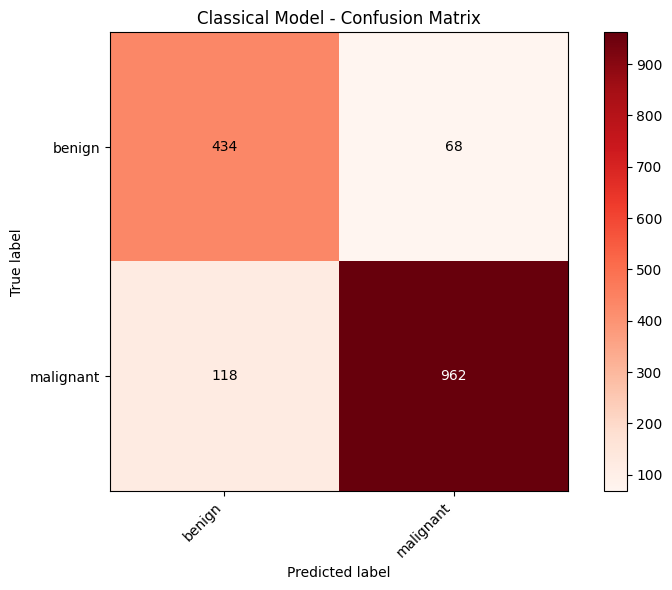


=== SUMMARY ===
Best Validation Accuracy (Classical Model): 0.8824


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

cm_c = confusion_matrix(all_labels_c, all_preds_c)
im = ax.imshow(cm_c, interpolation='nearest', cmap=plt.cm.Reds)
ax.set_title('Classical Model - Confusion Matrix')
ax.figure.colorbar(im, ax=ax)

ticks = np.arange(len(class_names))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

thresh = cm_c.max() / 2.
for i in range(cm_c.shape[0]):
    for j in range(cm_c.shape[1]):
        ax.text(j, i, format(cm_c[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_c[i, j] > thresh else 'black')

ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Best Validation Accuracy (Classical Model): {max(history_classical['val_acc']):.4f}")